In [1]:
%matplotlib inline
%reset -f

import os, random, time, sys, warnings

import numpy as np
import scipy as sp
import pandas as pd
from tqdm import tqdm
import bct

import torch

from src.topology import get_norm_rc, threshold_adj
from src.utils import get_weight_masks_schaefer, get_file_str, get_my_colors, get_slopes

# import plotting libraries
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")
from src.plotting import plot_accuracy_vs_feature

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
# directories
datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model'
topodir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/topology'
outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

file_str = 'task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-sa_axis'
print(file_str)

task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-sa_axis


In [3]:
fig_width = 2.5
fig_height = 1.75
segment_size = 15
feature_trim = 45

In [4]:
# load data
log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
test_accuracy = log_args['test_accuracy'][:, 1:feature_trim+1]
test_accuracy.shape

(100, 45)

In [5]:
color_palette1 = get_my_colors(cat_trio=True, as_list=True)
color_palette2 = sns.color_palette('Set2')

# Model performance vs. topology

In [6]:
log_args = np.load(os.path.join(topodir, file_str + '_trimmed-epochs-76_topology-degree.npy'), allow_pickle=True).item()
degree_skewness = log_args['degree_skewness']
degree_trimmed_mean = log_args['degree_trimmed_mean']

log_args = np.load(os.path.join(topodir, file_str + '_trimmed-epochs-76_topology-modularity.npy'), allow_pickle=True).item()
modularity_directed = log_args['modularity_directed']
participation_coefficient = log_args['participation_coefficient'].mean(axis=-1)

log_args = np.load(os.path.join(topodir, file_str + '_trimmed-epochs-76_topology-richclub.npy'), allow_pickle=True).item()
rich_club_mean = log_args['rich_club_mean']

features = [degree_skewness, degree_trimmed_mean, modularity_directed, participation_coefficient, rich_club_mean]
feature_labels = ['Degree', 'Degree', 'Modularity', 'Integration', 'Rich club']

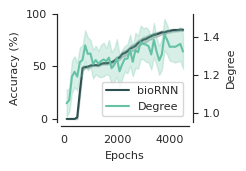

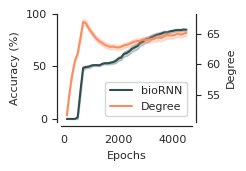

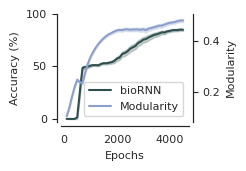

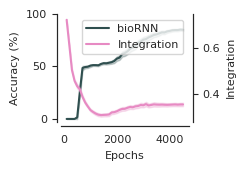

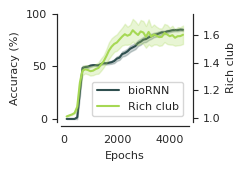

In [7]:
for i in np.arange(len(features)):
    f = plot_accuracy_vs_feature(test_accuracy, feature=features[i][:, :feature_trim], rnn_label='bioRNN', feature_label=feature_labels[i],
                                 fig_width=fig_width, fig_height=fig_height, accuracy_color='darkslategray', feature_color=color_palette2[i])
    f.savefig(os.path.join(outdir, '{0}_{1}.svg'.format(file_str, i)), dpi=600, bbox_inches='tight', pad_inches=0.01)

    # slopes = get_slopes(feature, segment_size=segment_size)
    # f = plot_accuracy_vs_feature(test_accuracy, feature=slopes, rnn_label='bioRNN', feature_label='slope', fig_width=fig_width, fig_height=fig_height)
    # f.savefig(os.path.join(outdir, '{0}_{1}-slopes.svg'.format(file_str, key)), dpi=600, bbox_inches='tight', pad_inches=0.01)

# Model performance vs. slopes of topological features

(100, 75, 5)


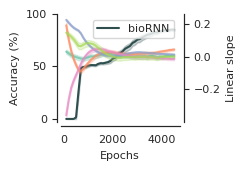

In [8]:
slopes = []
for feature in features:
    slopes.append(get_slopes(feature, segment_size=segment_size))

slopes = np.transpose(np.asarray(slopes), (1, 2, 0))
print(slopes.shape)

plot_trim = 45
f = plot_accuracy_vs_feature(test_accuracy[:, :plot_trim], feature=slopes[:, :plot_trim, :], rnn_label='bioRNN', feature_label='Linear slope',
                             fig_width=fig_width, fig_height=fig_height, accuracy_color='darkslategray', feature_color=color_palette2)
f.savefig(os.path.join(outdir, '{0}_{1}.svg'.format(file_str, 'slopes')), dpi=600, bbox_inches='tight', pad_inches=0.01)